In [95]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(323)
tf.keras.utils.set_random_seed(323)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [96]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "previous_dv0_withstraw_sipCAdded.xlsx",
    "dv0_withoutstraw_sipCAdded.xlsx",
     
    "dv0_withstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [97]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143


In [98]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (134974, 82)
Global Participant_ID range: 6 … 143


In [99]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134969,4024,1750725782000,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134970,4025,1750725782200,1595,1593,1578,1577,1573,1573,1572,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134971,4026,1750725782400,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0
134972,4027,1750725782600,1595,1591,1578,1577,1574,1573,1575,1564,...,7.7,water,n,0,0,False,False,5,0.0,0


In [100]:
df = df_all

In [101]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [102]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 8                                   # 1 = ragged, >1 = padded


In [103]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# # ====================================================================
# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:                                # ← drop empty sip
#         skip_count += 1
#         continue
#     X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
#     y.append(dV)

# y = np.asarray(y, np.float32)
# X = np.array(X, dtype=object)   # each element is still a (T,64) array
# print(f"Total sips kept : {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", y.min(), "max:", y.max())

In [104]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================

# df = df[df["Label"] == 1]                        # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=0.01):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- You control this threshold: sips longer than this will be augmented
# AUGMENT_IF_LONGER_THAN = 15  # You can change this

# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     X.append(sip_frames)
#     y.append(dV)

#     # Augment only if sip is long
#     if T > AUGMENT_IF_LONGER_THAN:
#         # 1. Add Gaussian noise
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         # 2. Flip horizontally
#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))


In [105]:
# # ====================================================================
# # 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# # ====================================================================


# df = df[df["Label"] == 1]  # keep only annotated frames

# feature_cols = df.columns[2:66]
# seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# # --- Augmentation Functions ---
# def add_gaussian_noise(sip, std_dev=40):
#     """Add Gaussian noise to the sip (T, 64)."""
#     noise = np.random.normal(0, std_dev, sip.shape)
#     return sip + noise

# def flip_horizontal(sip):
#     """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
#     flipped = []
#     for frame in sip:
#         frame_8x8 = frame.reshape(8, 8)
#         flipped_frame = np.fliplr(frame_8x8).flatten()
#         flipped.append(flipped_frame)
#     return np.array(flipped, dtype=np.float32)

# # --- Thresholds you control
# AUGMENT_IF_LONGER_THAN = 15           # Regular augmentation if T > this
# MORE_AUGMENT_IF_LONGER_THAN = 20      # Extra augmentation if T > this
# NUM_EXTRA_NOISY_COPIES = 5            # Number of additional noise versions for long sips
# NUM_EXTRA_NOISY_COPIES_2 =3
# MORE_AUGMENT_IF_LONGER_THAN_2= 34
# # --- Main data list
# X, y = [], []
# skip_count = 0

# for _, g in df.groupby(seq_keys, sort=False):
#     dV = float(g[label_col].iloc[0])
#     if dV == 0.0:
#         skip_count += 1
#         continue

#     sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
#     T = len(sip_frames)

#     # Original sip
#     X.append(sip_frames)
#     y.append(dV)

#     # Moderate-length sip → 1 noise + 1 flip
#     if T > AUGMENT_IF_LONGER_THAN:
#         noisy_sip = add_gaussian_noise(sip_frames)
#         X.append(noisy_sip)
#         y.append(dV)

#         flipped_sip = flip_horizontal(sip_frames)
#         X.append(flipped_sip)
#         y.append(dV)

#     # Extra-long sip → multiple noise augmentations
#     if T > MORE_AUGMENT_IF_LONGER_THAN:
#         for _ in range(NUM_EXTRA_NOISY_COPIES):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)
#     if T > MORE_AUGMENT_IF_LONGER_THAN_2:
#         for _ in range(NUM_EXTRA_NOISY_COPIES_2):
#             noisy_version = add_gaussian_noise(sip_frames)
#             X.append(noisy_version)
#             y.append(dV)        

# # Final conversion to array
# X = np.array(X, dtype=object)   # each sip is still (T, 64)
# y = np.array(y, dtype=np.float32)

# print(f"Total sips kept (including augmented): {len(X)}")
# print(f"Zero-volume skipped : {skip_count}")
# print("Label stats  → min:", min(y), "max:", max(y))



In [106]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array) – SKIP zero-volume sips – APPLY AUGMENTATION
# ====================================================================

df = df[df["Label"] == 1]  # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

# --- Augmentation Functions ---
def add_gaussian_noise(sip):
    sigma_ratio = 0.1 # 20% of the maximum value (4000)
    std_dev = sigma_ratio * 4000
    """Add Gaussian noise to the sip (T, 64), ensuring non-negative values."""
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)  # Ensure no negative values

def flip_horizontal(sip):
    """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

# --- Rotation Functions for 20, 40, ..., 340 degrees ---
def rotate_frame(frame, angle):
    """Rotate a single 8x8 frame by a given angle (in degrees)."""
    from scipy.ndimage import rotate
    frame_8x8 = frame.reshape(8, 8)
    # reshape back to (8,8) after rotation, use reshape=False to keep shape
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

def rotate_sip(sip, angle):
    """Rotate all frames in a sip (T, 64) by a given angle (in degrees)."""
    return np.array([rotate_frame(frame, angle) for frame in sip], dtype=np.float32)

# Generate rotation functions for each angle
# rotation_angles = list(range(45, 360, 45))
rotation_angles = [5, 355, 10, 350, 20 ,340, 30, 330, 45, 315]
def get_all_rotations(sip):
    """Return a list of all rotated versions of sip for angles 20, 40, ..., 340."""
    return [rotate_sip(sip, angle) for angle in rotation_angles]

# --- Thresholds you control
AUGMENT_IF_LONGER_THAN = 25           # Regular augmentation if T > this
MORE_AUGMENT_IF_LONGER_THAN = 25      # Extra augmentation if T > this
NUM_EXTRA_NOISY_COPIES = 10            # Number of additional noise versions for long sips
NUM_EXTRA_NOISY_COPIES_2 =5
MORE_AUGMENT_IF_LONGER_THAN_2= 34

# --- Main data list
X, y, is_original = [], [], []
y_before_aug = []   # NEW: to store dV values before augmentation

skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:
        skip_count += 1
        continue

    sip_frames = g[feature_cols].to_numpy(np.float32)  # shape (T, 64)
    T = len(sip_frames)

    # Original sip
    X.append(sip_frames)
    y.append(dV)
    y_before_aug.append(dV)
    is_original.append(True)
    # Moderate-length sip → 1 noise + 1 flip + all rotations
    if dV > AUGMENT_IF_LONGER_THAN:
        # noisy_sip = add_gaussian_noise(sip_frames)
        # is_original.append(False)
        # X.append(noisy_sip)
        # y.append(dV)
        
        flipped_sip = flip_horizontal(sip_frames)
        is_original.append(False)
        X.append(flipped_sip)
        y.append(dV)

    # Add all rotation augmentations (20, 40, ..., 340 degrees)
    rotated_sips = get_all_rotations(sip_frames)
    for rotated in rotated_sips:
        is_original.append(False)
        X.append(rotated)
        y.append(dV)

    if dV < 55 and 45 < dV :
        for _ in range(10):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV)     
    if dV < 75 and 65 < dV :
        for _ in range(10):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 
    if dV < 95 and 85 < dV :
        for _ in range(20):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 
    if dV < 85 and 80 < dV :
        for _ in range(7):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 
    # Extra-long sip → multiple noise augmentations
    # if dV > MORE_AUGMENT_IF_LONGER_THAN:
    #     for _ in range(NUM_EXTRA_NOISY_COPIES):
    #         noisy_version = add_gaussian_noise(sip_frames)
    #         X.append(noisy_version)
    #         y.append(dV)
    # if dV > MORE_AUGMENT_IF_LONGER_THAN_2:
    #     for _ in range(NUM_EXTRA_NOISY_COPIES_2):
    #         noisy_version = add_gaussian_noise(sip_frames)
    #         X.append(noisy_version)
    #         y.append(dV)        
    if dV < 5 :
        for _ in range(3):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 
    if 85<dV < 90 :
        for _ in range(7):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 
    if 110 < dV < 135 :
        for _ in range(30):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV)    
    if 135 < dV < 180 :
        for _ in range(25):
            noisy_version = add_gaussian_noise(sip_frames)
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV)      
    if 40 < dV :
        for _ in range(4):
            noisy_version = add_gaussian_noise(sip_frames)  
            is_original.append(False)
            X.append(noisy_version)
            y.append(dV) 

# Final conversion to array
X = np.array(X, dtype=object)   # each sip is still (T, 64)
y = np.array(y, dtype=np.float32)
y_before_aug = np.array(y_before_aug, dtype=np.float32)
is_original_1 = np.array(is_original, dtype=bool)

print(f"Total sips kept (including augmented): {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", min(y), "max:", max(y))
print(f"Original sips: {np.sum(is_original_1)}, Augmented sips: {np.sum(~is_original_1)}")

Total sips kept (including augmented): 7640
Zero-volume skipped : 2
Label stats  → min: 0.8 max: 160.2
Original sips: 561, Augmented sips: 7079


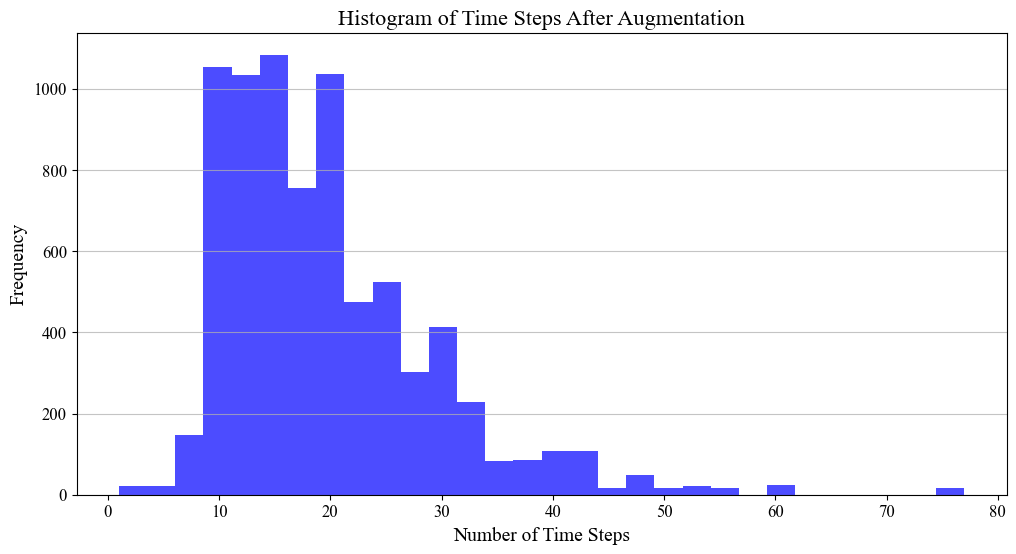

In [107]:
import matplotlib.pyplot as plt

# Get time step lengths for all sips
time_steps = [sip.shape[0] for sip in X]  # X is your final data after augmentation

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(time_steps, bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Time Steps After Augmentation')
plt.xlabel('Number of Time Steps')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


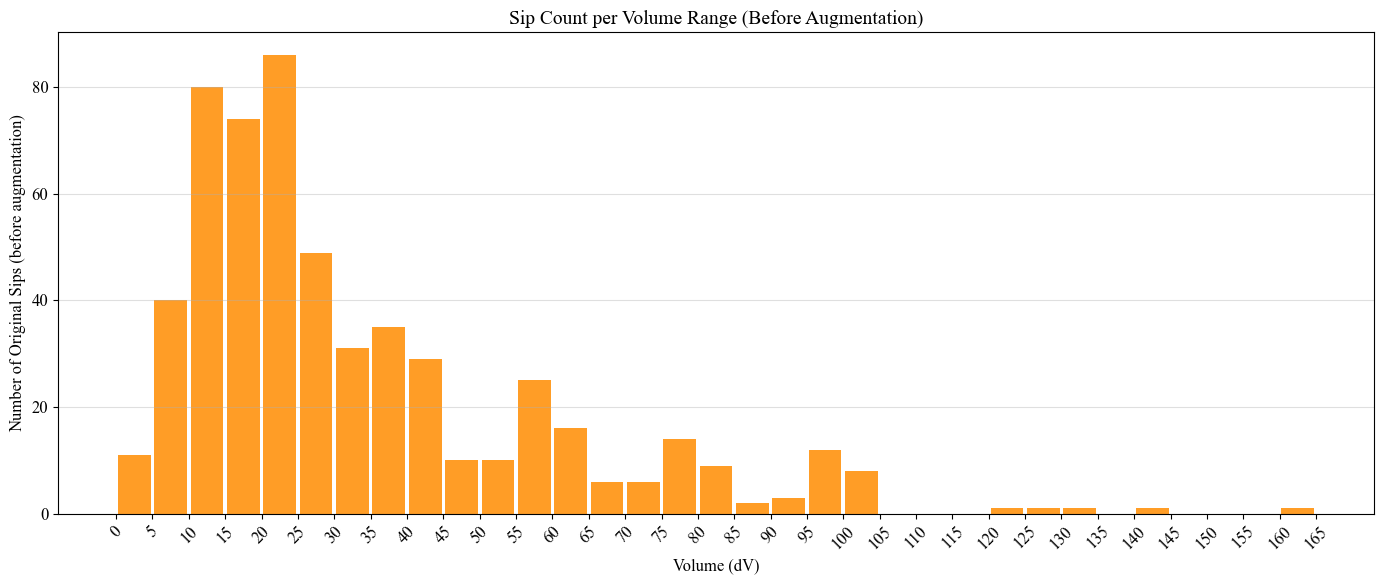

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh list for original (pre-augmentation) volumes
original_volumes = []

for _, g in df.groupby(["Participant_ID", "sip_id"], sort=False):
    dV = float(g["dV"].iloc[0])
    if dV == 0.0:
        continue
    original_volumes.append(dV)  # Only original sips, no augmentation

# Convert to NumPy array
original_volumes = np.array(original_volumes)

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(original_volumes) / bin_width) * bin_width)
max_vol = int(np.ceil(max(original_volumes) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize original_volumes into bins
bin_indices = np.digitize(original_volumes, volume_bins)
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many original sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):
        bin_counts[idx - 1] += 1

# Bin centers
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_before_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='darkorange', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Original Sips (before augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (Before Augmentation)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


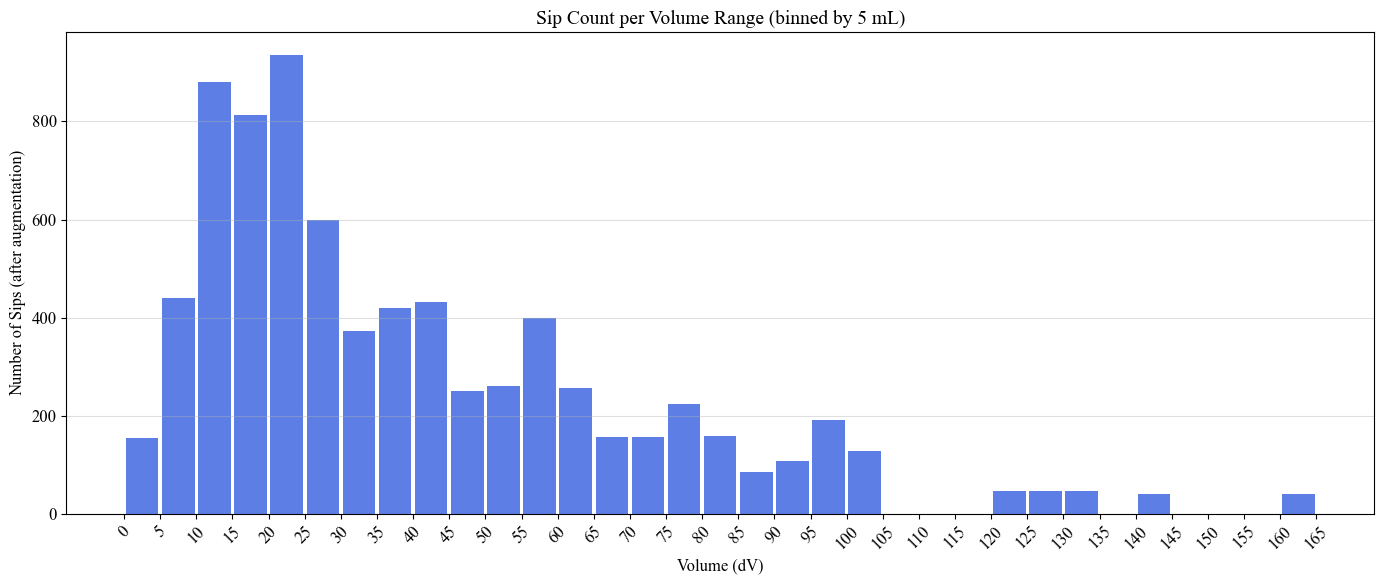

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
bin_width = 5  # mL
min_vol = int(np.floor(min(y) / bin_width) * bin_width)
max_vol = int(np.ceil(max(y) / bin_width) * bin_width)

# Create bins (e.g., [0, 5, 10, ..., 100])
volume_bins = np.arange(min_vol, max_vol + bin_width, bin_width)

# Digitize y into bins
bin_indices = np.digitize(y, volume_bins)  # assigns bin index
bin_counts = [0] * (len(volume_bins) - 1)

# Count how many sips fall into each bin
for idx in bin_indices:
    if 1 <= idx < len(volume_bins):  # skip out-of-range
        bin_counts[idx - 1] += 1

# Bin labels: midpoint of each bin (e.g., 2.5, 7.5, ...)
bin_centers = [(volume_bins[i] + volume_bins[i + 1]) / 2 for i in range(len(volume_bins) - 1)]

# Create DataFrame for export
df_export = pd.DataFrame({
    'Volume_Range': [f"{volume_bins[i]}-{volume_bins[i+1]}" for i in range(len(volume_bins)-1)],
    'Bin_Center': bin_centers,
    'Sip_Count': bin_counts
})

# Export to Excel
df_export.to_excel('sip_volume_distribution_after_augmentation.xlsx', index=False)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.bar(bin_centers, bin_counts, width=bin_width * 0.9, color='royalblue', alpha=0.85)
plt.xlabel('Volume (dV)', fontsize=12)
plt.ylabel('Number of Sips (after augmentation)', fontsize=12)
plt.title('Sip Count per Volume Range (binned by 5 mL)', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(np.arange(min_vol, max_vol + 1, bin_width), rotation=45)
plt.tight_layout()
plt.show()


In [110]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [111]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(7640,)
<class 'numpy.ndarray'>
(26, 64)


In [112]:
# # ====================================================================
# # 2. shuffle whole sips ➜ 80 / 20 split
# # ====================================================================
# original_indices = np.array([i for i, orig in enumerate(is_original) if orig])
# augmented_indices = np.array([i for i, orig in enumerate(is_original) if not orig])


# idx = rng.permutation(len(X))
# split1 = int(.64 * len(X))          # 64 % train
# split2 = int(.80 * len(X))          # next 16 % val
# X_train, y_train = X[idx[:split1]], y[idx[:split1]]
# X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
# X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
# print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# # y_train_s = np.log1p(y_train)        # log1p for numerical safety
# # y_val_s   = np.log1p(y_val)
# # y_test_s  = np.log1p(y_test)


In [113]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split (test set = only original data)
# ====================================================================
# Identify indices for original and augmented samples
original_indices = np.array([i for i, orig in enumerate(is_original) if orig])
augmented_indices = np.array([i for i, orig in enumerate(is_original) if not orig])

# Shuffle original indices for splitting test set
shuffled = rng.permutation(original_indices)
split1 = int(.8 * len(shuffled))  # 80% train/val, 20% test

test_idx = shuffled[split1:]
trainval_idx = np.concatenate([shuffled[:split1], augmented_indices])

# Now build your splits
X_test, y_test = X[test_idx], y[test_idx]
X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]

# Further split trainval into train/val (e.g., 80/20)
idx_tv = rng.permutation(len(X_trainval))
split_tv = int(.8 * len(X_trainval))
X_train, y_train = X_trainval[idx_tv[:split_tv]], y_trainval[idx_tv[:split_tv]]
X_val, y_val = X_trainval[idx_tv[split_tv:]], y_trainval[idx_tv[split_tv:]]

print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)

Train 6021 Val 1506  Test 113


In [114]:
print("Original data:", sum(is_original))
print("Augmented data:", len(is_original) - sum(is_original))
print("Total data:", len(is_original))
print(len(X), len(y), len(is_original))
print("Total sips kept (including augmented):", len(X))
print("Zero-volume skipped :", skip_count)
print("Label stats  → min:", np.min(y), "max:", np.max(y))
print("is_original length:", len(is_original))
print("Original data:", sum(is_original))
print("Augmented data:", len(is_original) - sum(is_original))
print("Total data (is_original):", len(is_original))
print("len(X):", len(X))
print("len(y):", len(y))
print("len(is_original):", len(is_original))

Original data: 561
Augmented data: 7079
Total data: 7640
7640 7640 7640
Total sips kept (including augmented): 7640
Zero-volume skipped : 2
Label stats  → min: 0.8 max: 160.2
is_original length: 7640
Original data: 561
Augmented data: 7079
Total data (is_original): 7640
len(X): 7640
len(y): 7640
len(is_original): 7640


In [115]:
# X_train


In [116]:
# y_train

In [117]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [118]:
# X_train

In [119]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [120]:
train_ds

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [121]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [122]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=3,
        dilations=[1,2,4,8,16,32,64],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    optimizer=Adagrad(learning_rate=0.01),
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=50, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=500,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCN)                     │ (None, 128)            │       673,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,793 (2.57 MB)

 Trainable params: 673,793 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - loss: 21.4558 - val_loss: 16.3984
Epoch 2/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 14.7120 - val_loss: 13.4039
Epoch 3/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 13.0531 - val_loss: 11.8224
Epoch 4/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 12.0700 - val_loss: 12.0193
Epoch 5/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 11.4285 - val_loss: 11.8726
Epoch 6/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 10.7665 - val_loss: 10.6200
Epoch 7/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - loss: 10.4328 - val_loss: 9.9030
Epoch 8/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - loss: 10.1210 - val_loss: 10.4668
Epoch 9/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 9.8968 - val_loss: 10.1633
Epoch 10/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - loss: 9.6695 - val_loss: 10.4423
Epoch 11/500
753/753 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 9.3372 - val_loss: 9.7065
Ep

In [123]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [124]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 113 test sips
  MSE   : 25.7098
  RMSE  : 5.0705
  R²    : 0.9334
  RMSPE : 33.66%

First 50 predictions:
    Actual dV  Predicted dV
0   60.000000     61.037720
1   20.600000     15.244248
2   12.732615     11.174955
3   37.599998     30.633030
4   34.378059     35.176182
5   22.600000     27.079666
6   48.000000     44.057617
7   28.795300     27.690607
8    9.990206     10.456915
9   20.337301     24.457729
10  11.142858      9.950005
11  33.900002     23.741747
12  40.000000     49.496998
13   9.162561      8.599763
14  36.630753     24.980459
15  39.682541     40.431393
16  20.666014     24.589483
17  27.678572     26.836018
18  15.100000     16.267824
19  80.000000     74.271675
20  13.428572     17.296894
21  11.111111     11.316904
22   6.660137     16.436747
23  27.904762     33.589401
24  16.571428     17.442947
25  17.809525     11.968846
26  15.083252     14.378547
27  32.419197     38.050930
28  15.088758     15.705149
29  39.682541     46.648960
30  25.4652

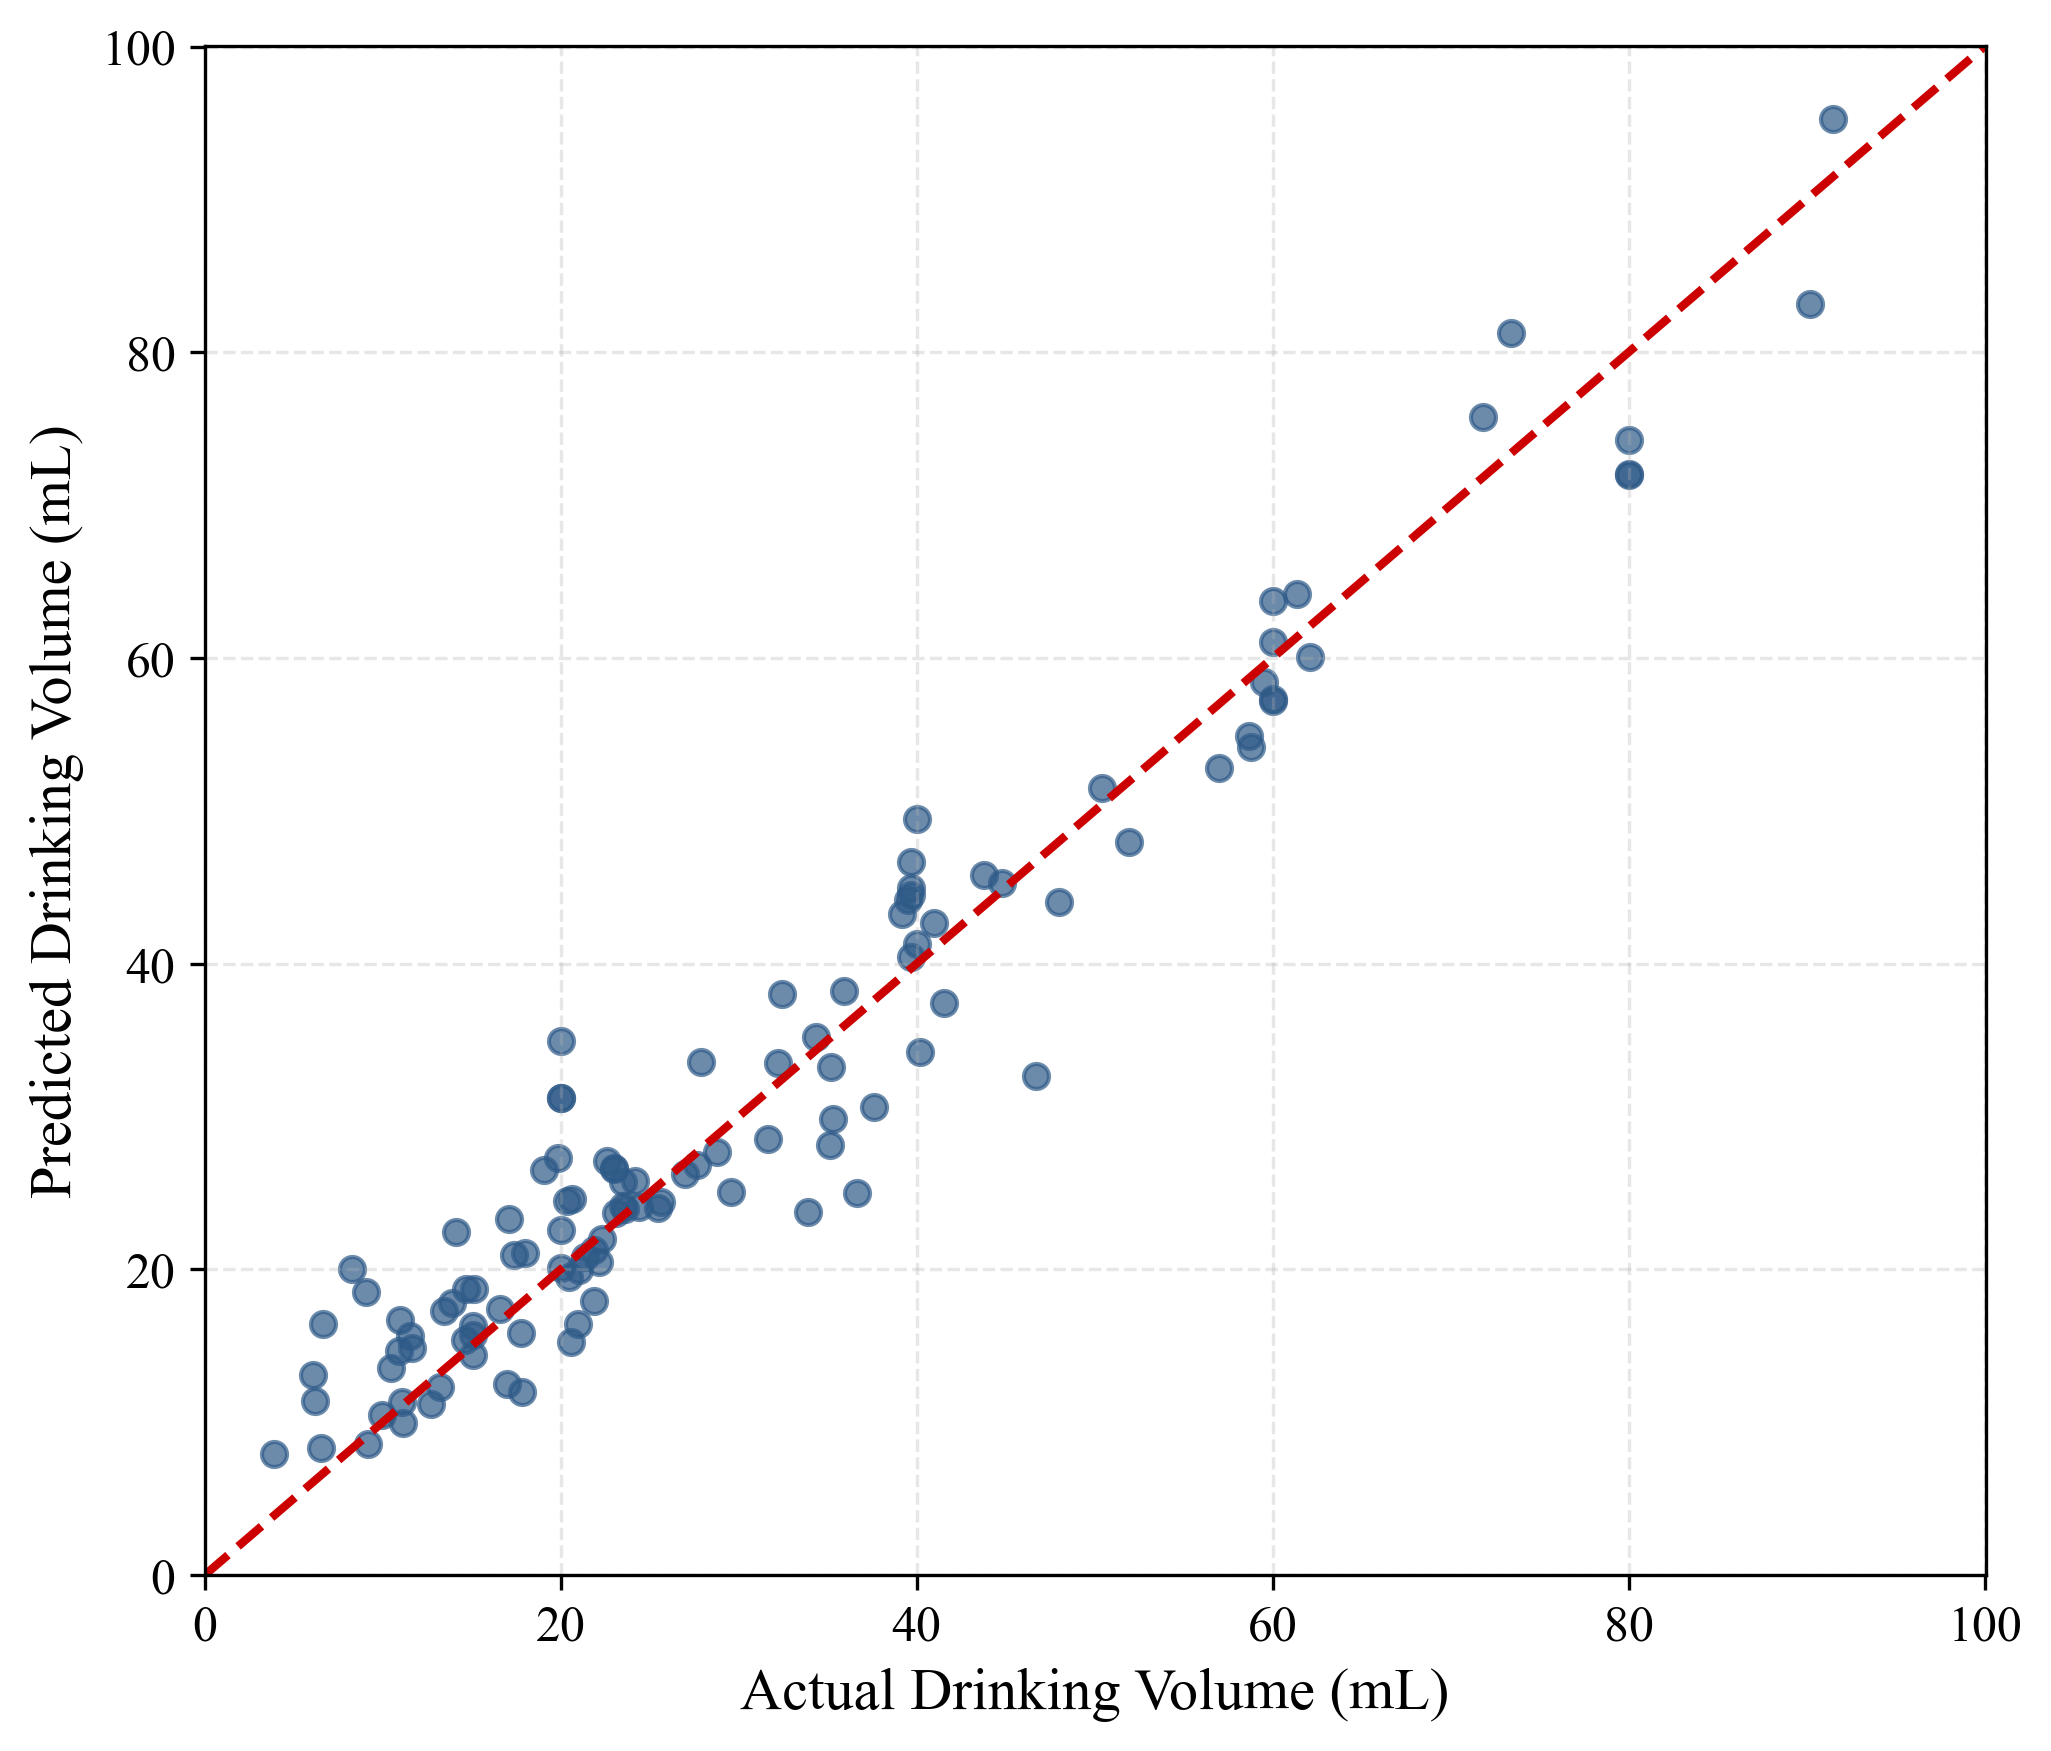

Results saved to 'tcn_predictions_both_regression.xlsx'
Plots saved as 'drinking_volume_prediction.pdf' and 'drinking_volume_prediction.png'


In [125]:
# ====================================================================
# 8. scatter plot and save data
# ====================================================================
plt.figure(figsize=(7, 6), dpi=300)  # Higher DPI for publication quality
plt.rcParams.update({
    'font.family': 'Times New Roman',  # Standard academic font
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

plt.scatter(y_test, y_pred, alpha=0.7, color='#2E5A88')  # Professional blue color
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "--", color='#CC0000', linewidth=2)  # Darker red for clarity
plt.xlim(lims); plt.ylim(lims)

plt.xlabel("Actual Drinking Volume (mL)")
plt.ylabel("Predicted Drinking Volume (mL)")
# Removed title for academic publication - figure caption will be used instead

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save high-quality figure for publication
plt.savefig('drinking_volume_prediction.pdf', format='pdf', bbox_inches='tight')
plt.savefig('drinking_volume_prediction.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Save predictions to Excel file for Tableau
results_df = pd.DataFrame({
    'Actual_Volume': y_test,
    'Predicted_Volume': y_pred
})
results_df.to_excel('tcn_predictions_both_regression.xlsx', index=False)
print("Results saved to 'tcn_predictions_both_regression.xlsx'")
print("Plots saved as 'drinking_volume_prediction.pdf' and 'drinking_volume_prediction.png'")

In [126]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [127]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 0.8 160.2
train_s min / max (log): -1.2986386 3.9293418
